# PIGNN v3 (RK4) — Evaluation Notebook
### Physics-Informed Graph Neural Network for BlueROV2 Dynamics

This notebook loads **pretrained weights** and runs evaluation immediately. Set `EVAL_ONLY = True` (default) to skip all training
cells and go straight to results.

**Results from the pretrained model:**
- VPT: 1.12 s
- Final position RMSE: 0.2853 m
- One-step dev loss: 3.32e-06

To retrain from scratch, set `EVAL_ONLY = False`.

- Peter M


## 1. Setup


In [ ]:
# Uncomment and run once to install dependencies:
!pip install torch torch-geometric numpy scipy matplotlib tqdm control numba tensorboard

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 13.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 578.3/578.3 kB 65.8 MB/s eta 0:00:00


In [ ]:
import os
import sys
import time

import numpy as np
import torch
import matplotlib.pyplot as plt
from IPython.display import display, HTML

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'PyTorch: {torch.__version__}')
print(f'CUDA:    {torch.cuda.is_available()}')
print(f'Device:  {device}')

# ── Evaluation mode flag ─────────────────────────────────────────────
# Set EVAL_ONLY = True to skip training and load pretrained weights.
# Set EVAL_ONLY = False to run full training from scratch.
EVAL_ONLY = True
print(f'Mode: {"EVAL ONLY — loading pretrained weights" if EVAL_ONLY else "TRAINING — will train from scratch"}')


PyTorch: 2.10.0+cu128
CUDA:    True
Device:  cuda


In [ ]:
# Download pretrained weights from GitHub Release
CKPT_DIR        = '/tmp/pignn_v3_weights'
BEST_MODEL_PATH = os.path.join(CKPT_DIR, 'best_model_v3.pt')
CKPT_PATH       = os.path.join(CKPT_DIR, 'training_checkpoint_v3.pt')
os.makedirs(CKPT_DIR, exist_ok=True)

WEIGHTS_URL = 'https://github.com/PMUSKET2/PIGNN_UUV_3/releases/download/v3-weights/pignn_v3_weights.zip'
WEIGHTS_ZIP = '/tmp/pignn_v3_weights.zip'

if not os.path.exists(BEST_MODEL_PATH):
    print('Downloading pretrained weights from GitHub...')
    import urllib.request
    urllib.request.urlretrieve(WEIGHTS_URL, WEIGHTS_ZIP)
    import zipfile
    with zipfile.ZipFile(WEIGHTS_ZIP, 'r') as z:
        z.extractall(CKPT_DIR)
    print(f'Weights extracted to {CKPT_DIR}')
else:
    print('Weights already present, skipping download.')

print(f'Files: {os.listdir(CKPT_DIR)}')


Mounted at /content/drive
Checkpoint dir: /content/drive/MyDrive/PIGNN_v3_checkpoints
Existing files: ['best_model_v3.pt', 'training_checkpoint_v3.pt']


## 2. Data Generation

Simulate BlueROV2 trajectories using the 4-DOF Fossen model.
In `EVAL_ONLY` mode the dev set is generated for evaluation;
the full training set is skipped.


In [ ]:
# Clone the repo (force fresh clone if stale copy exists)
import os

REPO_URL = 'https://github.com/PMUSKET2/PIGNN_UUV_3.git'
REPO_DIR = '/content/PIGNN_UUV_3'

if os.path.isdir(REPO_DIR):
    # Remove stale clone so we get the latest version
    !rm -rf {REPO_DIR}

!git clone {REPO_URL} {REPO_DIR}

# Set working directory and Python path to the repo root
os.chdir(REPO_DIR)
if REPO_DIR not in sys.path:
    sys.path.insert(0, REPO_DIR)

# Verify the project structure exists
assert os.path.isdir('src'), f'ERROR: src/ not found in {os.listdir(".")}'
print(f'Working directory: {os.getcwd()}')
print(f'Contents: {sorted(os.listdir("."))}')


Cloning into '/content/PIGNN_UUV_3'...
remote: Enumerating objects: 38, done.
remote: Counting objects: 100% (38/38), done.
remote: Compressing objects: 100% (36/36), done.
remote: Total 38 (delta 8), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (38/38), 31.25 KiB | 2.08 MiB/s, done.
Resolving deltas: 100% (8/8), done.
Working directory: /content/PIGNN_UUV_3
Contents: ['.git', 'README.md', 'data', 'models', 'requirements.txt', 'scripts', 'src', 'tests', 'training']


In [ ]:
import control as ct
from src.bluerov import bluerov
from data.data_utility import random_input, random_x0
import numpy as np
import torch

np.random.seed(0)

rov_sys = ct.NonlinearIOSystem(
    bluerov, None,
    inputs=("X", "Y", "Z", "M_z"),
    outputs=("x", "y", "z", "psi", "u", "v", "w", "r"),
    states=("x", "y", "z", "psi", "u", "v", "w", "r"),
    name="bluerov_system",
)

def generate_dataset(name, n_traj, input_type, dt, T_tot, intervals, params=None):
    """Generate and save a trajectory dataset."""
    N = int(T_tot / dt)
    t = np.linspace(0, T_tot, N, dtype=np.float32)
    N_x, N_u = 9, 4

    X = np.zeros((n_traj, N, N_x), dtype=np.float32)
    U = np.zeros((n_traj, N, N_u), dtype=np.float32)
    t_coll = np.zeros((n_traj, N, 1), dtype=np.float32)

    for n in range(n_traj):
        x_0 = random_x0(intervals)
        U[n] = random_input(t, N_u, input_type, params=params)
        if input_type not in ("line", "circle", "figure8"):
            U[n, :, 1] *= 0.1
            U[n, :, 2] = 5 * np.abs(U[n, :, 2])
            U[n, :, -1] *= 0.05

        _, x = ct.input_output_response(rov_sys, t, U[n].T, x_0)
        x = x.T
        X[n, :, :3] = x[:, :3]
        X[n, :, 3] = np.cos(x[:, 3])
        X[n, :, 4] = np.sin(x[:, 3])
        X[n, :, 5:] = x[:, 4:]
        t_coll[n, :, 0] = dt

    os.makedirs(name, exist_ok=True)
    torch.save(torch.from_numpy(t), os.path.join(name, "t.pt"))
    torch.save(torch.from_numpy(U), os.path.join(name, "U.pt"))
    torch.save(torch.from_numpy(X), os.path.join(name, "X.pt"))
    torch.save(torch.from_numpy(t_coll), os.path.join(name, "t_coll.pt"))
    print(f"  {name}: {n_traj} trajectories, {N} steps each")
    return X, U, t


In [ ]:
# Generate datasets
# In EVAL_ONLY mode: generate only the dev set (needed for evaluation).
# In training mode: generate all four datasets.
dt, T_tot = 0.08, 5.2

eval_datasets = {
    "dev_set": {
        "n_traj": 20,
        "input_type": "sine",
        "intervals": [0.0] * 8,
    },
}

train_datasets = {
    "training_set": {
        "n_traj": 400,
        "input_type": "noise",
        "intervals": [1.0, 1.0, 1.0, np.pi, 1.0, 0.0, 0.1, 0.0],
    },
    "test_set_interp": {
        "n_traj": 20,
        "input_type": "sine",
        "intervals": [0.0] * 8,
        "dt": dt - 0.02,
        "T_tot": 3.9,
    },
    "test_set_extrap": {
        "n_traj": 20,
        "input_type": "sine",
        "intervals": [0.0] * 8,
        "dt": dt + 0.02,
        "T_tot": 6.5,
    },
}

datasets_to_generate = eval_datasets if EVAL_ONLY else {**eval_datasets, **train_datasets}

print(f'Generating {"dev set only" if EVAL_ONLY else "all datasets"}...')
generated = {}
for name, cfg in datasets_to_generate.items():
    d = cfg.get('dt', dt)
    T = cfg.get('T_tot', T_tot)
    X, U, t = generate_dataset(name, cfg['n_traj'], cfg['input_type'], d, T, cfg['intervals'])
    generated[name] = (X, U, t)

print('Done!')


Generating datasets...
  training_set: 400 trajectories, 65 steps each
  dev_set: 20 trajectories, 65 steps each
  test_set_interp: 20 trajectories, 65 steps each
  test_set_extrap: 20 trajectories, 65 steps each

Done!


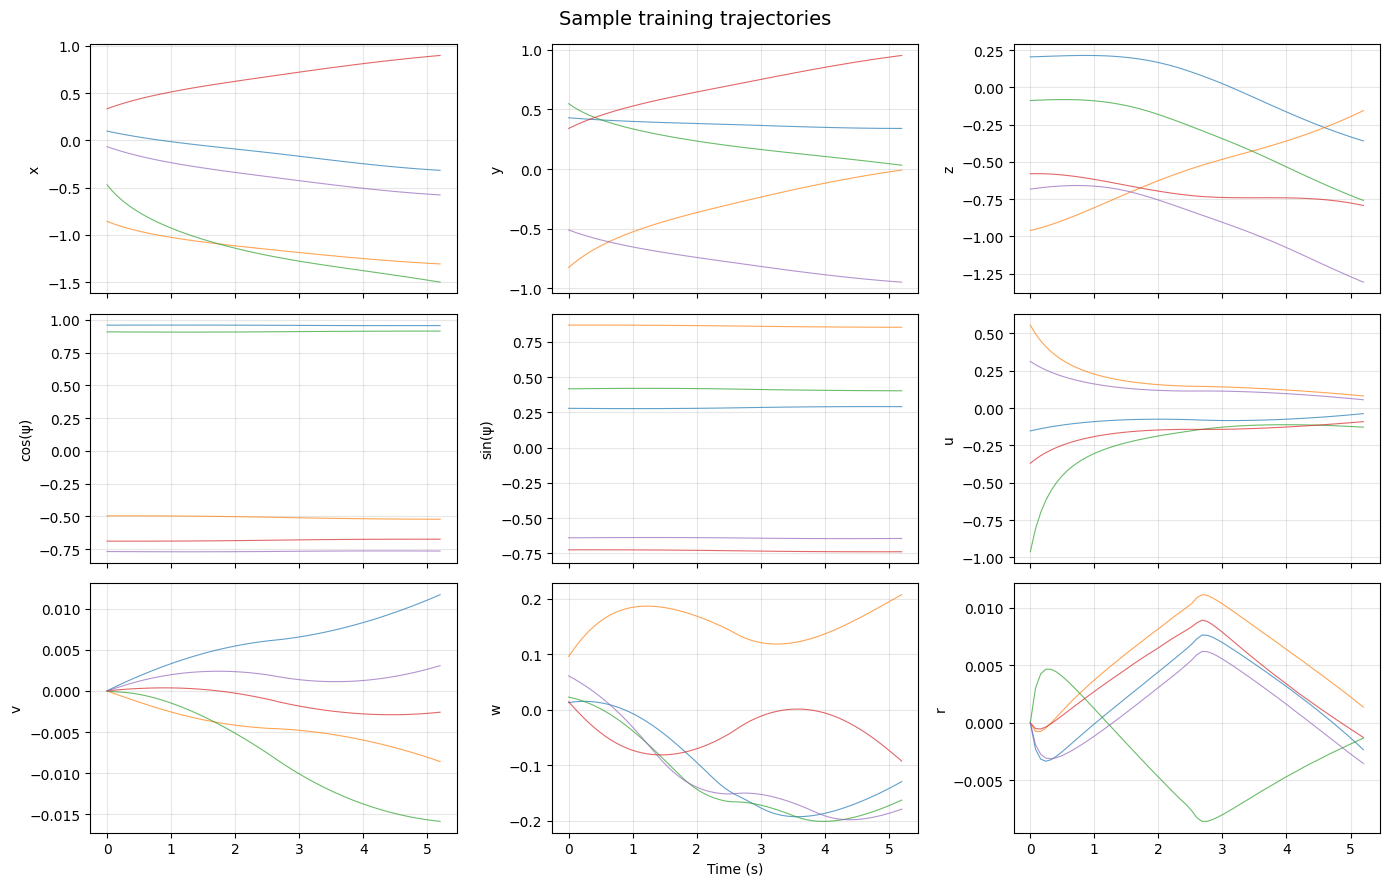

In [ ]:
# Visualise sample trajectories
# In EVAL_ONLY mode, uses dev set since training set is not generated.
if EVAL_ONLY:
    X_vis, U_vis, t_vis = generated['dev_set']
    plot_title = 'Sample dev set trajectories'
else:
    X_vis, U_vis, t_vis = generated['training_set']
    plot_title = 'Sample training trajectories'

state_labels = ['x', 'y', 'z', 'cos(ψ)', 'sin(ψ)', 'u', 'v', 'w', 'r']
fig, axes = plt.subplots(3, 3, figsize=(14, 9), sharex=True)
for s, ax in enumerate(axes.flatten()):
    for j in range(min(5, X_vis.shape[0])):
        ax.plot(t_vis, X_vis[j, :, s], alpha=0.7, linewidth=0.8)
    ax.set_ylabel(state_labels[s])
    ax.grid(True, alpha=0.3)
axes[-1, 1].set_xlabel('Time (s)')
fig.suptitle(plot_title, fontsize=14)
plt.tight_layout()
plt.show()


## 3. Graph Structure Inspection

Build a sample graph and inspect its topology — this is the core novelty of the PIGNN approach.

In [ ]:
from models.graph_builder import build_graph, allocate_thrusts, NUM_THRUSTERS

# Build a sample graph — use dev set in EVAL_ONLY mode
if EVAL_ONLY:
    X_sample, U_sample, _ = generated['dev_set']
else:
    X_sample, U_sample, _ = generated['training_set']

sample_state = torch.tensor(X_sample[0, 0], dtype=torch.float32)
sample_tau   = torch.tensor(U_sample[0, 0], dtype=torch.float32)

graph = build_graph(sample_state, sample_tau)

print("=== Heterogeneous Graph Structure ===")
print(f"\nNode types:")
for ntype in graph.node_types:
    x = graph[ntype].x
    print(f"  {ntype:20s}  nodes={x.shape[0]}, features={x.shape[1]}")

print(f"\nEdge types:")
for etype in graph.edge_types:
    ei = graph[etype].edge_index
    ea = graph[etype].edge_attr
    name = f"{etype[0]} --[{etype[1]}]--> {etype[2]}"
    print(f"  {name:45s}  edges={ei.shape[1]}, edge_feat_dim={ea.shape[1]}")

print(f"\nTotal nodes: {sum(graph[nt].x.shape[0] for nt in graph.node_types)}")
print(f"Total edges: {sum(graph[et].edge_index.shape[1] for et in graph.edge_types)}")

=== Heterogeneous Graph Structure ===

Node types:
  hull                  nodes=1, features=9
  thruster              nodes=8, features=8
  hydrodynamic          nodes=1, features=4
  buoyancy              nodes=1, features=6

Edge types:
  thruster --[forces]--> hull                    edges=8, edge_feat_dim=7
  hydrodynamic --[drag]--> hull                  edges=1, edge_feat_dim=8
  buoyancy --[restoring]--> hull                 edges=1, edge_feat_dim=4

Total nodes: 11
Total edges: 10


In [ ]:
# Verify hard constraint: all edges target hull
print("Hard constraint check — all edges target hull:")
for etype in graph.edge_types:
    target = etype[2]
    status = "✓" if target == "hull" else "✗ VIOLATION"
    print(f"  {etype[0]:15s} → {target:10s}  {status}")

# Inspect thruster allocation
print(f"\nThruster allocation for τ = {sample_tau.numpy()}:")
f_alloc = allocate_thrusts(sample_tau.unsqueeze(0)).squeeze()
for i in range(NUM_THRUSTERS):
    print(f"  Thruster {i}: f = {f_alloc[i].item():.4f} N")

Hard constraint check — all edges target hull:
  thruster        → hull        ✓
  hydrodynamic    → hull        ✓
  buoyancy        → hull        ✓

Thruster allocation for τ = [ 0.5720218   0.12271368  4.402594   -0.02195813]:
  Thruster 0: f = 0.0731 N
  Thruster 1: f = 0.3314 N
  Thruster 2: f = 0.0137 N
  Thruster 3: f = -0.4182 N
  Thruster 4: f = 1.1006 N
  Thruster 5: f = 1.1006 N
  Thruster 6: f = 1.1006 N
  Thruster 7: f = 1.1006 N


## 4. Model, RK4 Integrator & Training

In `EVAL_ONLY` mode the training cells are skipped — the pretrained
weights downloaded in Cell 4 are loaded directly in Cell 16.

| | v2 (discrete) | v3 (RK4) |
|---|---|---|
| Model output | next state x̂(t+dt) | derivative ẋ(t) |
| Integration | residual connection (Euler) | RK4 (4 evaluations, O(dt⁵) error) |
| Physics loss | AD/jvp through discrete transition | direct: compare ẋ to Fossen RHS |


In [ ]:
from models.pignn import PIGNN
from models.model_utility import (
    get_data_sets,
    convert_input_data,
    convert_output_data,
    project_heading,
    weighted_mse_loss,
    get_state_weights,
)
from src.bluerov_torch import bluerov_compute

# ── RK4 integrator (standalone — model predicts ẋ, not x̂) ──────────────
# The model forward pass now outputs the 9D state *derivative* ẋ at the
# current state/control. RK4 takes 4 evaluations at different sub-steps
# and integrates forward by dt with O(dt⁵) local truncation error.
#
# This replaces the Euler-style residual connection in v2. The graph
# structure, message passing, and readout are unchanged — only the
# interpretation of what the readout head produces has changed.
#
# Note: the model receives Z = [state | control | dt] as input (14-dim).
# pignn.py (v3) applies the body→world rotation prior internally and returns
# ẋ directly — no residual addition or unit-circle projection inside forward().
# rk4_step handles heading projection after each integration step.

def rk4_step(model, x, u, dt):
    """
    Advance state x by one RK4 step of size dt.

    Parameters
    ----------
    model : PIGNN (outputs ẋ, shape (B, 9))
    x     : (B, 9)  current state
    u     : (B, 4)  control input (constant over [t, t+dt])
    dt    : float   time step

    Returns
    -------
    x_next : (B, 9)  state at t+dt, with heading projected onto S¹
    """
    device = x.device
    dt_feat = torch.full((x.shape[0], 1), dt, device=device, dtype=x.dtype)

    def f(state):
        # Project heading before each evaluation so the graph is built
        # from a valid (cos ψ, sin ψ) pair.
        state = project_heading(state)
        Z = torch.cat([state, u, dt_feat], dim=-1)
        return model(Z)   # (B, 9)  — derivative ẋ

    k1 = f(x)
    k2 = f(x + 0.5 * dt * k1)
    k3 = f(x + 0.5 * dt * k2)
    k4 = f(x + dt * k3)

    x_next = x + (dt / 6.0) * (k1 + 2*k2 + 2*k3 + k4)
    return project_heading(x_next)


# ── Sanity check: forward pass ───────────────────────────────────────────
# The model now outputs ẋ (derivative), so we validate shape and confirm
# the heading projection in rk4_step produces unit-norm headings.
model = PIGNN(N_in=14, N_out=9, hidden=64, msg_dim=64, n_mp_layers=2).to(device)  # hidden=64 (up from 32)

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Model parameters: {n_params:,}")

# Test derivative output
x_test = torch.randn(4, 9, device=device)
u_test = torch.randn(4, 4, device=device)
x_test_proj = project_heading(x_test)  # ensure valid heading input
Z_test = torch.cat([x_test_proj, u_test, torch.full((4, 1), 0.08, device=device)], dim=-1)
xdot_test = model(Z_test)
print(f"Derivative output: input {Z_test.shape} -> ẋ {xdot_test.shape}")
assert xdot_test.shape == (4, 9), "Output shape mismatch!"

# Test full RK4 step
x_next_test = rk4_step(model, x_test_proj, u_test, dt=0.08)
norms = torch.sqrt(x_next_test[:, 3]**2 + x_next_test[:, 4]**2)
print(f"RK4 step output shape: {x_next_test.shape}")
print(f"Heading norms after RK4 (should be ~1.0): {norms.detach().cpu().numpy()}")
print("RK4 sanity check OK")


Model parameters: 111,316
Derivative output: input torch.Size([4, 14]) -> ẋ torch.Size([4, 9])
RK4 step output shape: torch.Size([4, 9])
Heading norms after RK4 (should be ~1.0): [1. 1. 1. 1.]
RK4 sanity check OK


In [ ]:
if not EVAL_ONLY:
    # --- Training Configuration (v3 — RK4) ---
    BATCH_SIZE = 32
    LR_FACTOR = 0.5
    LR_MIN = 1e-5
    ALPHA_SMOOTH = 0.6
    DEMO_MODE = False

    PHASES = [
        {'name': 'phase1_data_physics', 'pinn': True,  'rollout': False, 'n_roll': 0,
         'max_epochs': 400, 'patience': 60, 'lr_patience': 30, 'lr_init': 8e-3},
        {'name': 'phase2_rollout',      'pinn': True,  'rollout': True,  'n_roll': 10,
         'max_epochs': 300, 'patience': 50, 'lr_patience': 25, 'lr_init': 2e-3},
    ]

    from torch.utils.data import DataLoader
    from data.data_utility import TrajectoryDataset
    train_ds = TrajectoryDataset('training_set')
    dev_ds   = TrajectoryDataset('dev_set')
    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
    dev_loader   = DataLoader(dev_ds,   batch_size=BATCH_SIZE, shuffle=False)
    state_weights = get_state_weights(device=device)
    print(f'Training: {len(train_ds)} trajectories | Dev: {len(dev_ds)} trajectories')
else:
    from torch.utils.data import DataLoader
    from data.data_utility import TrajectoryDataset
    dev_ds     = TrajectoryDataset('dev_set')
    dev_loader = DataLoader(dev_ds, batch_size=32, shuffle=False)
    state_weights = get_state_weights(device=device)
    print(f'EVAL_ONLY: skipping training setup. Dev set: {len(dev_ds)} trajectories.')


Training:   400 trajectories
Validation: 20 trajectories
Batch size: 32
Mode:       FULL

Per-state loss weights:
           x: 0.0540
           y: 0.2158
           z: 0.0396
    cos(psi): 0.0540
    sin(psi): 0.0540
           u: 0.4856
           v: 5.3958
           w: 0.7588
           r: 1.9425


In [ ]:
import json as _json
from torch.optim import AdamW
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torch.nn.functional import mse_loss
from tqdm.notebook import trange


# ── RK4-based loss functions ──────────────────────────────────────────────

def rk4_data_loss(model, X, U, dt, state_weights=None):
    """
    One-step data loss via RK4 integration.

    Takes x(t), u(t) → RK4 → x̂(t+dt), compares to x(t+1).
    Because RK4 makes 4 model evaluations per step, this already captures
    multi-step structure better than the v2 Euler residual.

    X    : (B, T, 9)
    U    : (B, T, 4)
    dt   : float
    """
    x_in  = X[:, :-1, :].reshape(-1, 9)   # (B*(T-1), 9)
    u_in  = U[:, :-1, :].reshape(-1, 4)   # (B*(T-1), 4)
    x_tgt = X[:, 1:,  :].reshape(-1, 9)   # (B*(T-1), 9)

    x_pred = rk4_step(model, x_in, u_in, dt)

    if state_weights is not None:
        return weighted_mse_loss(x_pred, x_tgt, state_weights)
    return mse_loss(x_pred, x_tgt)


def rk4_physics_loss(model, X, U, dt):
    """
    Direct physics loss — no AD required.

    Because the model now outputs ẋ directly, the physics loss is simply
    the MSE between the model's derivative and the Fossen RHS evaluated
    at the same (state, control) point. No jvp / AD through a discrete
    transition needed.

    X : (B, T, 9)
    U : (B, T, 4)
    """
    x_flat = X.reshape(-1, 9)              # (B*T, 9)
    u_flat = U.reshape(-1, 4)              # (B*T, 4)

    dt_feat = torch.full((x_flat.shape[0], 1), dt,
                         device=x_flat.device, dtype=x_flat.dtype)
    Z = torch.cat([project_heading(x_flat), u_flat, dt_feat], dim=-1)
    xdot_pred = model(Z)                   # (B*T, 9) — model's derivative

    xdot_physics = bluerov_compute(0, x_flat, u_flat)  # Fossen RHS
    return mse_loss(xdot_pred, xdot_physics)


def rk4_rollout_loss(model, X, U, dt, n_roll, state_weights=None):
    """
    Multi-step rollout loss via RK4 steps.

    Autoregressively rolls out n_roll steps from a random start offset
    and accumulates MSE against ground truth.

    X : (B, T, 9)
    U : (B, T, 4)
    """
    N_seq = X.shape[1]
    N_slice = N_seq - n_roll
    x_hat = X[:, :N_slice, :].reshape(-1, 9)  # start states
    l_roll = 0.0

    for i in range(n_roll):
        u_i = U[:, i:i + N_slice, :].reshape(-1, 4)
        x_hat = rk4_step(model, x_hat, u_i, dt)
        x_tgt = X[:, i + 1:i + 1 + N_slice, :].reshape(-1, 9)
        if state_weights is not None:
            l_roll += weighted_mse_loss(x_hat, x_tgt, state_weights)
        else:
            l_roll += mse_loss(x_hat, x_tgt)

    return l_roll / n_roll


# ── Checkpoint helpers ────────────────────────────────────────────────

def save_checkpoint(path, model, phase_idx, epoch, best_dev_loss, best_state, history, phase_boundaries):
    torch.save({
        'model_state': model.state_dict(),
        'phase_idx': phase_idx,
        'epoch_in_phase': epoch,
        'best_dev_loss': best_dev_loss,
        'best_state': best_state,
        'history': history,
        'phase_boundaries': phase_boundaries,
    }, path)

def load_checkpoint(path, model, device):
    ckpt = torch.load(path, map_location=device, weights_only=False)
    model.load_state_dict(ckpt['model_state'])
    return ckpt


CKPT_PATH       = os.path.join(CKPT_DIR, 'training_checkpoint_v3.pt')
BEST_MODEL_PATH = os.path.join(CKPT_DIR, 'best_model_v3.pt')

# Instantiate model (needed in both eval and training modes)
model = PIGNN(N_in=14, N_out=9, hidden=64, msg_dim=64, n_mp_layers=2).to(device)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Model parameters: {n_params:,}')

history = {'train_data': [], 'train_phys': [], 'train_roll': [], 'dev_data': [], 'lr': [], 'phase': []}
best_dev_loss    = float('inf')
best_state       = None
global_epoch     = 0
phase_boundaries = []

# ── Load weights (EVAL_ONLY) or train ────────────────────────────────
if EVAL_ONLY:
    print('EVAL_ONLY mode — loading pretrained weights...')
    if os.path.exists(CKPT_PATH):
        ckpt = load_checkpoint(CKPT_PATH, model, device)
        best_state       = ckpt['best_state']
        history          = ckpt['history']
        phase_boundaries = ckpt['phase_boundaries']
        best_dev_loss    = ckpt['best_dev_loss']
        global_epoch     = len(history['train_data'])
        print(f'  Loaded checkpoint: {global_epoch} epochs, best dev loss: {best_dev_loss:.6f}')
    elif os.path.exists(BEST_MODEL_PATH):
        best_state = torch.load(BEST_MODEL_PATH, map_location=device, weights_only=True)
        print('  Loaded best_model_v3.pt (no training history available)')
    else:
        raise FileNotFoundError(
            'No weights found. Check that the zip downloaded correctly in Cell 4.'
        )
    model.load_state_dict(best_state)
    model.eval()
    print('Model ready for evaluation.')

else:
    # ── Full training loop ────────────────────────────────────────────
    start_phase_idx      = 0
    start_epoch_in_phase = 0

    if os.path.exists(CKPT_PATH):
        print('Found checkpoint - resuming...')
        ckpt = load_checkpoint(CKPT_PATH, model, device)
        loaded_phase = ckpt['phase_idx']
        if loaded_phase >= len(PHASES):
            print(f'  All {len(PHASES)} phases already completed!')
            start_phase_idx = len(PHASES)
            best_dev_loss    = ckpt['best_dev_loss']
            best_state       = ckpt['best_state']
            history          = ckpt['history']
            phase_boundaries = ckpt['phase_boundaries']
            global_epoch     = len(history['train_data'])
        else:
            start_phase_idx      = loaded_phase
            start_epoch_in_phase = ckpt['epoch_in_phase'] + 1
            best_dev_loss        = ckpt['best_dev_loss']
            best_state           = ckpt['best_state']
            history              = ckpt['history']
            phase_boundaries     = ckpt['phase_boundaries']
            global_epoch         = len(history['train_data'])
    else:
        print('No checkpoint found — starting from scratch.')

    from tqdm.notebook import trange
    from torch.optim import AdamW
    from torch.optim.lr_scheduler import ReduceLROnPlateau

    for phase_idx in range(start_phase_idx, len(PHASES)):
        phase = PHASES[phase_idx]
        print(f'\n{"="*60}')
        print(f'Phase {phase_idx+1}/{len(PHASES)}: {phase["name"]}')
        print(f'{"="*60}')

        optimizer = AdamW(model.parameters(), lr=phase['lr_init'], weight_decay=1e-4)
        scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=LR_FACTOR,
                                      patience=phase['lr_patience'], min_lr=LR_MIN)
        no_improve = 0
        best_phase_loss = float('inf')

        if global_epoch > 0 and (
            not phase_boundaries or phase_boundaries[-1][1] != phase['name']
        ):
            phase_boundaries.append((global_epoch, phase['name']))

        epoch_start = start_epoch_in_phase if phase_idx == start_phase_idx else 0

        for ep in trange(epoch_start, phase['max_epochs'], desc=phase['name']):
            model.train()
            train_data_loss = train_phys_loss = train_roll_loss = 0.0
            n_batches = 0

            for X_b, U_b, t_coll_b, time_b in train_loader:
                X_b = X_b.to(device); U_b = U_b.to(device)
                l_data = rk4_data_loss(model, X_b, U_b, dt, state_weights)
                l_phys = rk4_physics_loss(model, X_b, U_b, dt) if phase['pinn'] else torch.tensor(0.0, device=device)
                l_roll = rk4_rollout_loss(model, X_b, U_b, dt, phase['n_roll'], state_weights) if phase['rollout'] and phase['n_roll'] > 0 else torch.tensor(0.0, device=device)
                l_total = l_data + 0.5 * l_phys + l_roll
                optimizer.zero_grad(); l_total.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
                optimizer.step()
                train_data_loss += l_data.item(); train_phys_loss += l_phys.item()
                train_roll_loss += l_roll.item(); n_batches += 1

            n_batches = max(n_batches, 1)
            avg_data = train_data_loss / n_batches
            avg_phys = train_phys_loss / n_batches
            avg_roll = train_roll_loss / n_batches

            model.eval()
            dev_loss = sum(rk4_data_loss(model, X_d.to(device), U_d.to(device), dt, state_weights).item()
                          for X_d, U_d, _, __ in dev_loader)
            avg_dev = dev_loss / max(len(dev_loader), 1)
            scheduler.step(avg_dev)
            current_lr = optimizer.param_groups[0]['lr']

            history['train_data'].append(avg_data); history['train_phys'].append(avg_phys)
            history['train_roll'].append(avg_roll); history['dev_data'].append(avg_dev)
            history['lr'].append(current_lr); history['phase'].append(phase_idx)
            global_epoch += 1

            smooth_dev = (ALPHA_SMOOTH * avg_dev + (1 - ALPHA_SMOOTH) * best_phase_loss
                          if best_phase_loss < float('inf') else avg_dev)
            if smooth_dev < best_dev_loss:
                best_dev_loss = smooth_dev
                best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
                torch.save(best_state, BEST_MODEL_PATH)
            if smooth_dev < best_phase_loss: best_phase_loss = smooth_dev; no_improve = 0
            else: no_improve += 1
            if ep % 10 == 0:
                save_checkpoint(CKPT_PATH, model, phase_idx, ep, best_dev_loss, best_state, history, phase_boundaries)
                print(f'  ep {ep:4d} | data {avg_data:.4e} | phys {avg_phys:.4e} | roll {avg_roll:.4e} | dev {avg_dev:.4e} | lr {current_lr:.2e}')
            if no_improve >= phase['patience']:
                print(f'  Early stop at epoch {ep}'); break

        save_checkpoint(CKPT_PATH, model, phase_idx + 1, 0, best_dev_loss, best_state, history, phase_boundaries)
        start_epoch_in_phase = 0

    print(f'Training complete. Best dev loss: {best_dev_loss:.6f}')


Found checkpoint - resuming...
  All 2 phases already completed!
  Best dev loss: 0.000003
  Delete checkpoint to retrain: /content/drive/MyDrive/PIGNN_v3_checkpoints/training_checkpoint_v3.pt

Training complete. Best dev loss: 0.000003


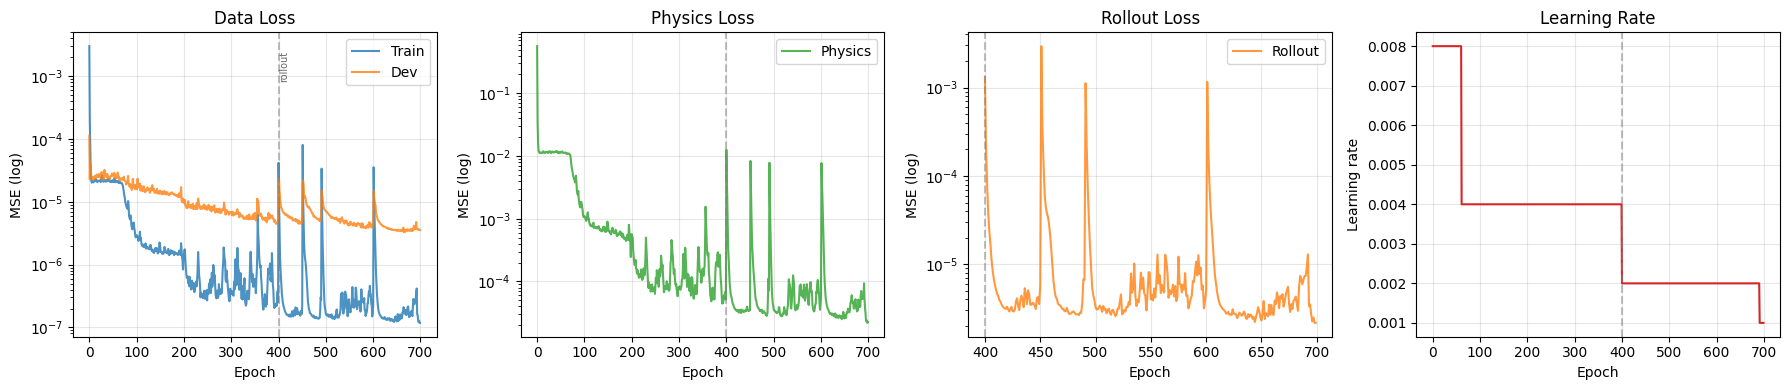

In [ ]:
# Training curves — only meaningful after training; shows loaded history in EVAL_ONLY mode
if not history['train_data']:
    print('No training history available (weights loaded without checkpoint history).')
else:
    # Plot training curves with phase boundaries
    fig, axes = plt.subplots(1, 4, figsize=(18, 4))

    # Data loss
    axes[0].semilogy(history['train_data'], label='Train', alpha=0.8)
    axes[0].semilogy(history['dev_data'], label='Dev', alpha=0.8)
    for ep, name in phase_boundaries:
        axes[0].axvline(x=ep, color='gray', linestyle='--', alpha=0.5)
        axes[0].text(ep+1, axes[0].get_ylim()[1]*0.5, name.split('_',1)[1],
                    fontsize=7, rotation=90, va='top', alpha=0.6)
    axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('MSE (log)')
    axes[0].set_title('Data Loss'); axes[0].legend(); axes[0].grid(True, alpha=0.3)

    # Physics loss
    axes[1].semilogy(history['train_phys'], label='Physics', color='C2', alpha=0.8)
    for ep, _ in phase_boundaries:
        axes[1].axvline(x=ep, color='gray', linestyle='--', alpha=0.5)
    axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('MSE (log)')
    axes[1].set_title('Physics Loss'); axes[1].legend(); axes[1].grid(True, alpha=0.3)

    # Rollout loss
    roll_data = history['train_roll']
    if any(v > 0 for v in roll_data):
        # Only plot non-zero rollout epochs
        roll_epochs = [i for i, v in enumerate(roll_data) if v > 0]
        roll_vals = [roll_data[i] for i in roll_epochs]
        axes[2].semilogy(roll_epochs, roll_vals, label='Rollout', color='C1', alpha=0.8)
        for ep, _ in phase_boundaries:
            axes[2].axvline(x=ep, color='gray', linestyle='--', alpha=0.5)
        axes[2].legend()
    else:
        axes[2].text(0.5, 0.5, 'No rollout phases ran', ha='center', va='center',
                    transform=axes[2].transAxes)
    axes[2].set_xlabel('Epoch'); axes[2].set_ylabel('MSE (log)')
    axes[2].set_title('Rollout Loss'); axes[2].grid(True, alpha=0.3)

    # Learning rate
    axes[3].plot(history['lr'], color='C3')
    for ep, _ in phase_boundaries:
        axes[3].axvline(x=ep, color='gray', linestyle='--', alpha=0.5)
    axes[3].set_xlabel('Epoch'); axes[3].set_ylabel('Learning rate')
    axes[3].set_title('Learning Rate'); axes[3].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


## 5. Evaluation — Rollout Predictions

Load the best model and run autoregressive rollouts on the dev set.

In [ ]:
# Ensure model is in eval mode with best weights loaded
# (Already handled in Cell 16 — this cell is a safety net)
if best_state is not None and not EVAL_ONLY:
    # In training mode, reload best weights after training loop
    model.load_state_dict(best_state)

model.eval()
model = model.to(device)
print('Model ready for evaluation.')

def rollout(model, X_gt, U, dt):
    """
    Autoregressive RK4 rollout from the first time-step.

    Parameters
    ----------
    model : PIGNN (outputs ẋ)
    X_gt  : (1, T, 9)  ground-truth trajectory
    U     : (1, T, 4)  control inputs
    dt    : float      time step

    Returns
    -------
    X_pred : (T, 9)  predicted trajectory as numpy array
    """
    T = X_gt.shape[1]
    X_pred = torch.zeros(T, 9, device=device)
    X_pred[0] = X_gt[0, 0]

    with torch.no_grad():
        for t in range(T - 1):
            x_cur = X_pred[t].unsqueeze(0)
            u_cur = U[:, t, :]
            X_pred[t + 1] = rk4_step(model, x_cur, u_cur, dt).squeeze(0)

    return X_pred.cpu().numpy()


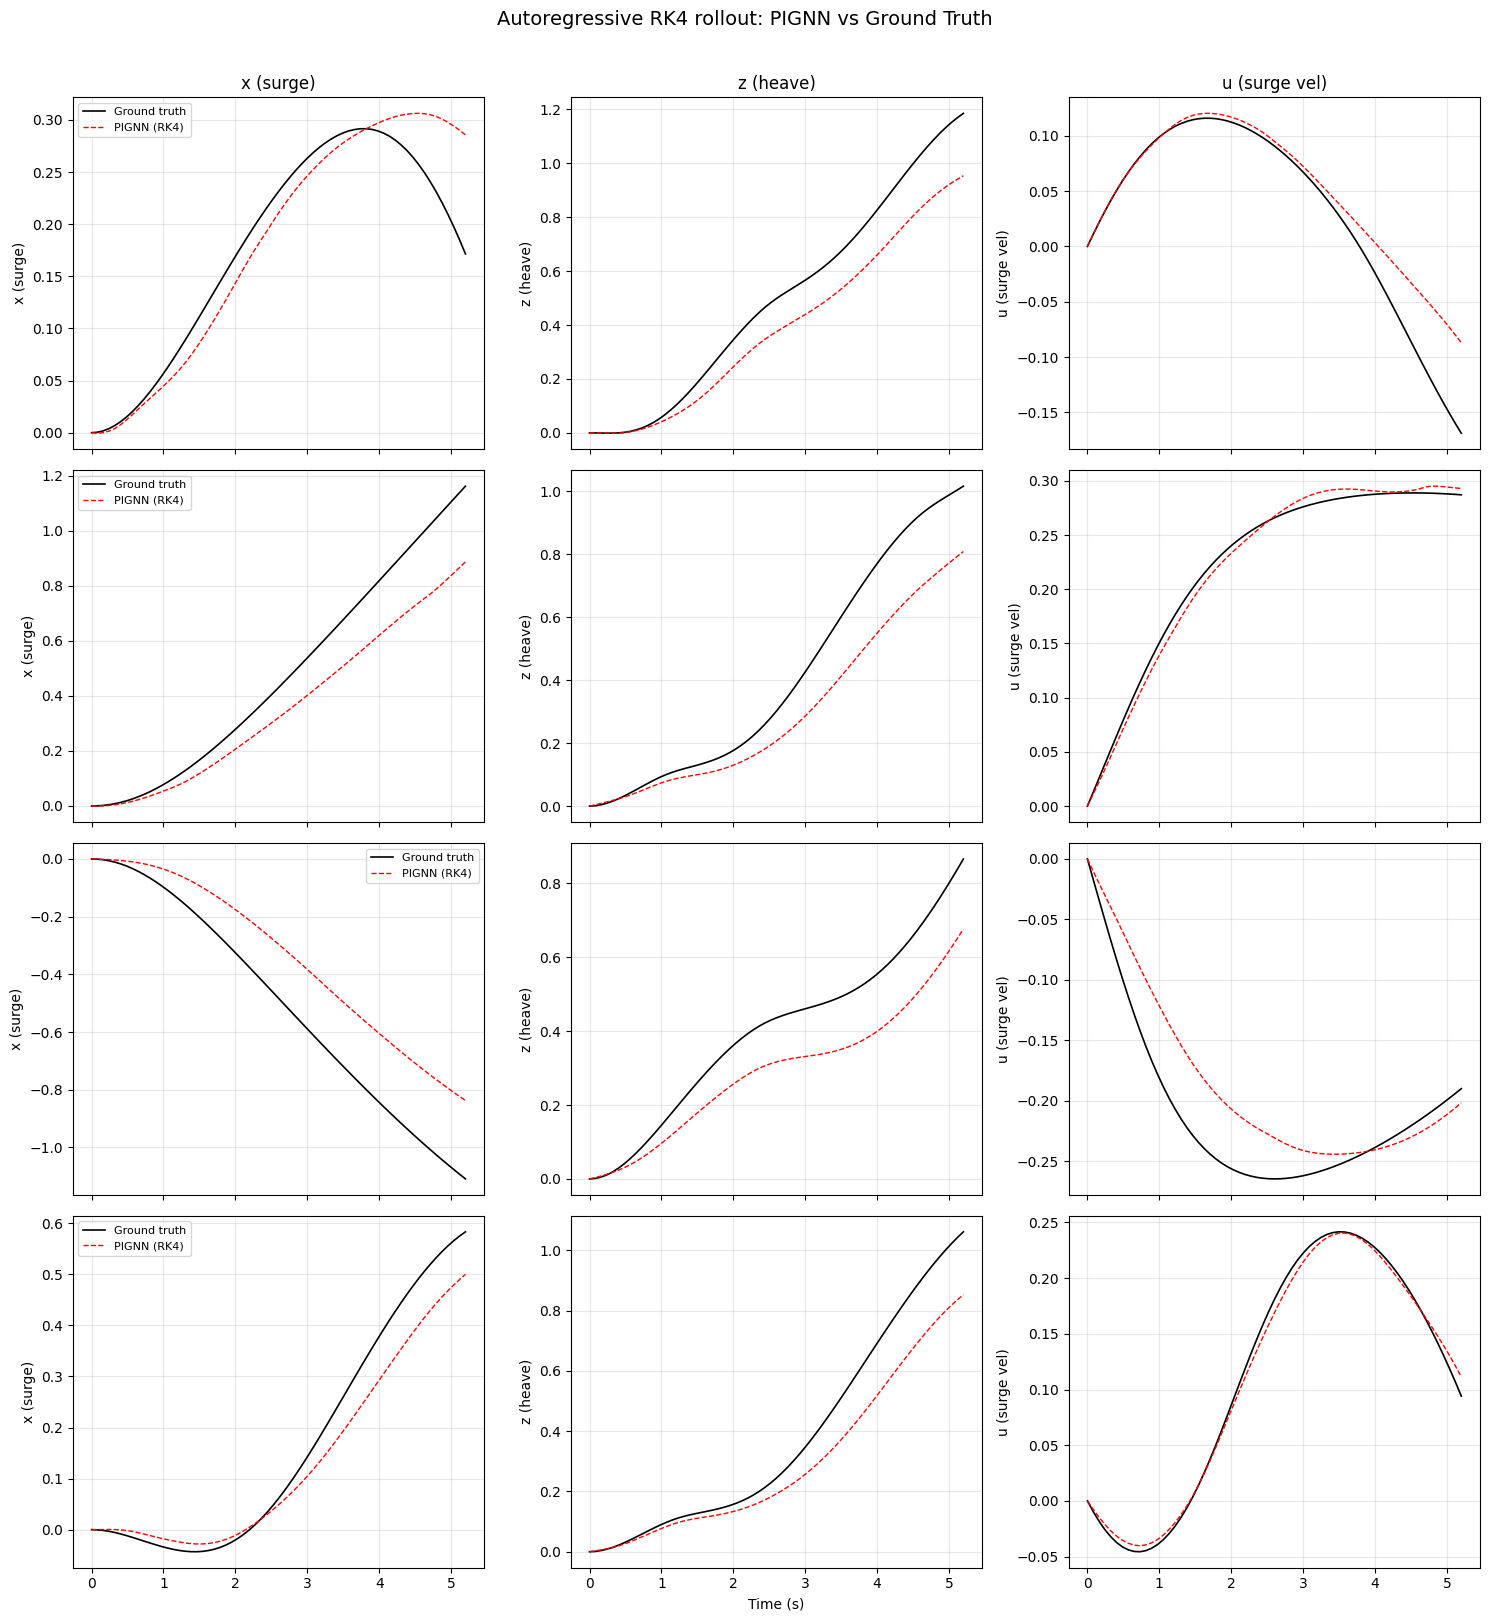

In [ ]:
# Evaluate on a few dev-set trajectories
n_eval = min(4, len(dev_ds))
indices = np.random.choice(len(dev_ds), n_eval, replace=False)

fig, all_axes = plt.subplots(n_eval, 3, figsize=(15, 4 * n_eval), sharex=True)
if n_eval == 1:
    all_axes = all_axes[np.newaxis, :]

plot_states = [0, 2, 5]  # x, z, u
plot_labels = ["x (surge)", "z (heave)", "u (surge vel)"]

for row, idx in enumerate(indices):
    X_gt, U_gt, tc, tm = dev_ds[idx]
    X_gt_b = X_gt.unsqueeze(0).to(device)
    U_b    = U_gt.unsqueeze(0).to(device)

    X_pred  = rollout(model, X_gt_b, U_b, dt)
    X_gt_np = X_gt.numpy()
    t_axis  = tm[:, 0].numpy()

    for col, (si, sl) in enumerate(zip(plot_states, plot_labels)):
        ax = all_axes[row, col]
        ax.plot(t_axis, X_gt_np[:, si], "k-",  linewidth=1.2, label="Ground truth")
        ax.plot(t_axis, X_pred[:, si],  "r--", linewidth=1.0, label="PIGNN (RK4)")
        ax.set_ylabel(sl)
        ax.grid(True, alpha=0.3)
        if row == 0:
            ax.set_title(sl)
        if col == 0:
            ax.legend(fontsize=8)

all_axes[-1, 1].set_xlabel("Time (s)")
fig.suptitle("Autoregressive RK4 rollout: PIGNN vs Ground Truth", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()


In [ ]:
# ============================================================
# Comprehensive Evaluation Metrics
# ============================================================

state_labels_9 = ['x', 'y', 'z', 'cos(psi)', 'sin(psi)', 'u', 'v', 'w', 'r']
state_labels_8 = ['x [m]', 'y [m]', 'z [m]', 'psi [rad]',
                   'u [m/s]', 'v [m/s]', 'w [m/s]', 'r [rad/s]']
DT = 0.08

def reparam_to_8d(states_9):
    """Convert 9D (cos/sin psi) back to 8D (psi) for position/heading metrics."""
    cos_psi = states_9[..., 3]
    sin_psi = states_9[..., 4]
    psi = np.arctan2(sin_psi, cos_psi)
    return np.concatenate([
        states_9[..., :3],
        psi[..., np.newaxis],
        states_9[..., 5:]
    ], axis=-1)

# Run rollouts on all dev trajectories
n_eval = min(20, len(dev_ds))
all_pred_9 = []  # predicted trajectories (9D)
all_gt_9 = []    # ground truth trajectories (9D)

print(f'Running rollouts on {n_eval} dev trajectories...')
for idx in range(n_eval):
    X_gt, U_gt, tc, tm = dev_ds[idx]
    X_gt_b = X_gt.unsqueeze(0).to(device)
    U_b = U_gt.unsqueeze(0).to(device)
    X_pred = rollout(model, X_gt_b, U_b, dt)
    all_pred_9.append(X_pred)
    all_gt_9.append(X_gt.numpy())

all_pred_9 = np.stack(all_pred_9)  # (N_eval, T, 9)
all_gt_9 = np.stack(all_gt_9)      # (N_eval, T, 9)

# Convert to 8D for position/heading metrics
all_pred_8 = reparam_to_8d(all_pred_9)
all_gt_8 = reparam_to_8d(all_gt_9)

# --- 1. Per-state MAE (existing metric) ---
mae_per_state = np.abs(all_pred_9 - all_gt_9).mean(axis=(0, 1))

# --- 2. Position RMSE over time ---
pos_err = np.sqrt(np.sum((all_pred_8[:, :, :3] - all_gt_8[:, :, :3])**2, axis=-1))  # (N, T)
pos_rmse = np.sqrt(np.mean(pos_err**2, axis=0))  # (T,)

# --- 3. Heading RMSE over time ---
heading_err = np.arctan2(
    np.sin(all_pred_8[:, :, 3] - all_gt_8[:, :, 3]),
    np.cos(all_pred_8[:, :, 3] - all_gt_8[:, :, 3])
)  # (N, T)
heading_rmse = np.sqrt(np.mean(heading_err**2, axis=0))  # (T,)

# --- 4. Per-state RMSE over time (8D) ---
state_rmse = np.sqrt(np.mean((all_pred_8 - all_gt_8)**2, axis=0))  # (T, 8)

# --- 5. VPT (Valid Prediction Time) ---
mean_pos_err = np.mean(pos_err, axis=0)  # (T,)
exceeded = np.where(mean_pos_err > 0.05)[0]
vpt = exceeded[0] * DT if len(exceeded) > 0 else all_pred_9.shape[1] * DT

# --- Print summary ---
print(f'\n{"="*60}')
print(f'  PIGNN Evaluation Results')
print(f'{"="*60}')
print(f'\n  VPT:                 {vpt:.2f} s')
print(f'  Final pos RMSE:      {pos_rmse[-1]:.4f} m')
print(f'  Final heading RMSE:  {heading_rmse[-1]:.4f} rad')
print(f'  Max pos RMSE:        {pos_rmse.max():.4f} m')
print(f'  One-step dev loss:   {best_dev_loss:.4e}')

print(f'\nPer-state MAE (9D rollout):')
print(f'  {"-"*35}')
for s, label in enumerate(state_labels_9):
    print(f'  {label:>10s}: {mae_per_state[s]:.6f}')
print(f'  {"Overall":>10s}: {mae_per_state.mean():.6f}')


Running rollouts on 20 dev trajectories...

  PIGNN Evaluation Results

  VPT:                 1.12 s
  Final pos RMSE:      0.2853 m
  Final heading RMSE:  0.1006 rad
  Max pos RMSE:        0.2853 m
  One-step dev loss:   3.3231e-06

Per-state MAE (9D rollout):
  -----------------------------------
           x: 0.078791
           y: 0.024074
           z: 0.098593
    cos(psi): 0.001968
    sin(psi): 0.050760
           u: 0.019824
           v: 0.012465
           w: 0.028113
           r: 0.022794
     Overall: 0.037487


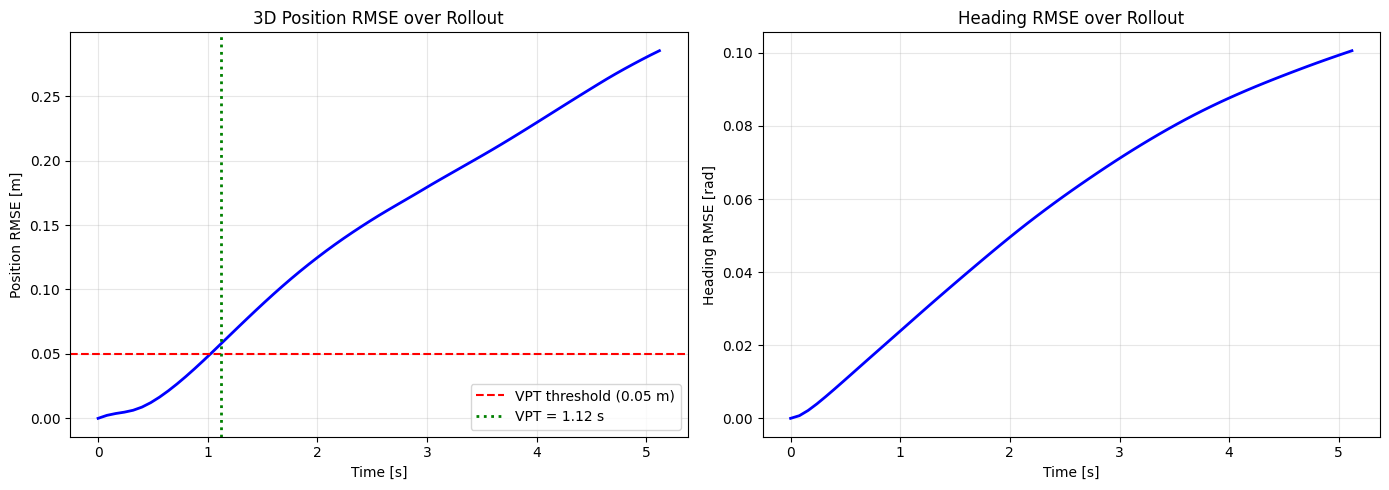

In [ ]:
# Position RMSE + Heading RMSE over time
t_rollout = np.arange(len(pos_rmse)) * DT

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Position RMSE
axes[0].plot(t_rollout, pos_rmse, 'b-', lw=2)
axes[0].axhline(y=0.05, color='r', ls='--', label='VPT threshold (0.05 m)')
axes[0].axvline(x=vpt, color='g', ls=':', lw=2, label=f'VPT = {vpt:.2f} s')
axes[0].set_xlabel('Time [s]')
axes[0].set_ylabel('Position RMSE [m]')
axes[0].set_title('3D Position RMSE over Rollout')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Heading RMSE
axes[1].plot(t_rollout, heading_rmse, 'b-', lw=2)
axes[1].set_xlabel('Time [s]')
axes[1].set_ylabel('Heading RMSE [rad]')
axes[1].set_title('Heading RMSE over Rollout')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


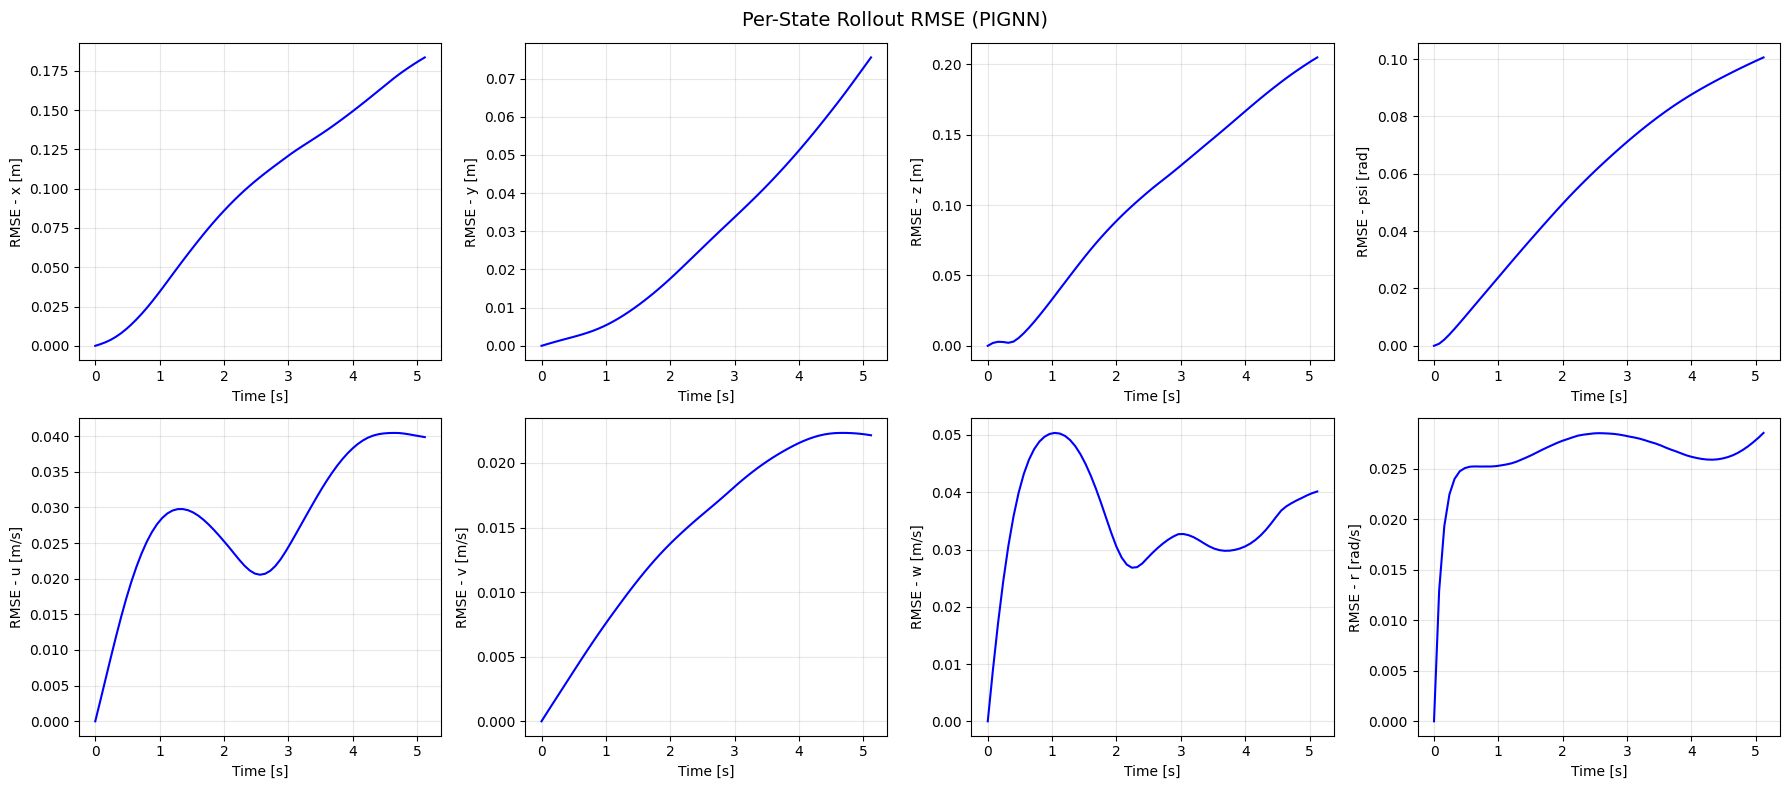

In [ ]:
# Per-state RMSE over time (8D physical states)
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for i, ax in enumerate(axes.flat):
    ax.plot(t_rollout, state_rmse[:, i], 'b-', lw=1.5)
    ax.set_ylabel(f'RMSE - {state_labels_8[i]}')
    ax.set_xlabel('Time [s]')
    ax.grid(True, alpha=0.3)
plt.suptitle('Per-State Rollout RMSE (PIGNN)', fontsize=14)
plt.tight_layout()
plt.show()


In [ ]:
# Per-state error summary
all_errors = []
for idx in range(min(20, len(dev_ds))):
    X_gt, U_gt, tc, tm = dev_ds[idx]
    X_gt_b = X_gt.unsqueeze(0).to(device)
    U_b = U_gt.unsqueeze(0).to(device)
    X_pred = rollout(model, X_gt_b, U_b, dt)
    all_errors.append(np.abs(X_pred - X_gt.numpy()))

all_errors = np.stack(all_errors)  # (N, T, 9)
mean_err = all_errors.mean(axis=(0, 1))

print("Mean Absolute Error per state variable (rollout):")
print("-" * 40)
for s, label in enumerate(state_labels):
    print(f"  {label:>8s}: {mean_err[s]:.6f}")
print(f"{'Overall':>10s}: {mean_err.mean():.6f}")

Mean Absolute Error per state variable (rollout):
----------------------------------------
         x: 0.078791
         y: 0.024074
         z: 0.098593
  cos(psi): 0.001968
  sin(psi): 0.050760
         u: 0.019824
         v: 0.012465
         w: 0.028113
         r: 0.022794
   Overall: 0.037487


In [ ]:
# Save the best model
os.makedirs("models_saved", exist_ok=True)
save_path = "models_saved/pignn_notebook_best.pt"
torch.save(best_state, save_path)
print(f"Model saved to {save_path}")

Model saved to models_saved/pignn_notebook_best.pt


## 6. Graph Visualisation

Visualise the heterogeneous graph topology using matplotlib.

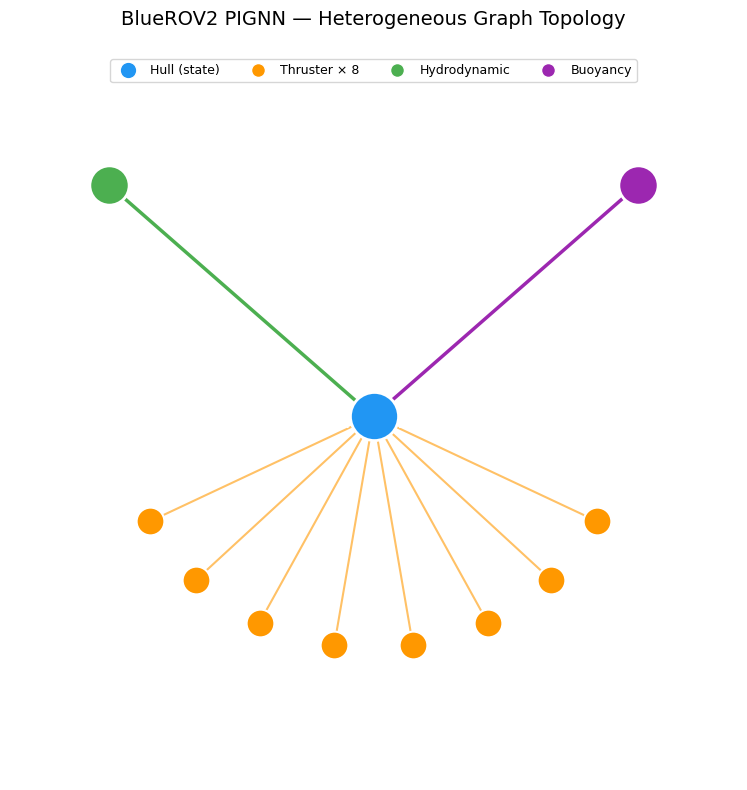

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(10, 8))

# Node positions for visualisation
positions = {
    "hull": (0.5, 0.5),
    "hydrodynamic": (0.1, 0.85),
    "buoyancy": (0.9, 0.85),
}
# Thrusters arranged in a semicircle below
for i in range(8):
    angle = np.pi * (0.15 + 0.7 * i / 7)
    positions[f"thruster_{i}"] = (0.5 + 0.38 * np.cos(angle), 0.5 - 0.35 * np.sin(angle))

colors = {
    "hull": "#2196F3",
    "thruster": "#FF9800",
    "hydrodynamic": "#4CAF50",
    "buoyancy": "#9C27B0",
}

# Draw edges
for i in range(8):
    tx, ty = positions[f"thruster_{i}"]
    hx, hy = positions["hull"]
    ax.annotate("", xy=(hx, hy), xytext=(tx, ty),
                arrowprops=dict(arrowstyle="->", color=colors["thruster"], lw=1.5, alpha=0.6))

for src in ["hydrodynamic", "buoyancy"]:
    sx, sy = positions[src]
    hx, hy = positions["hull"]
    ax.annotate("", xy=(hx, hy), xytext=(sx, sy),
                arrowprops=dict(arrowstyle="->", color=colors[src], lw=2.5))

# Draw nodes
ax.scatter(*positions["hull"], s=1200, c=colors["hull"], zorder=5, edgecolors="white", linewidth=2)
ax.text(*positions["hull"], "Hull\n(1 node)", ha="center", va="center", fontsize=9, fontweight="bold", color="white")

for i in range(8):
    px, py = positions[f"thruster_{i}"]
    ax.scatter(px, py, s=400, c=colors["thruster"], zorder=5, edgecolors="white", linewidth=1.5)
    ax.text(px, py, f"T{i}", ha="center", va="center", fontsize=7, fontweight="bold", color="white")

for ntype in ["hydrodynamic", "buoyancy"]:
    px, py = positions[ntype]
    ax.scatter(px, py, s=800, c=colors[ntype], zorder=5, edgecolors="white", linewidth=2)
    label = "Hydro\n(1 node)" if ntype == "hydrodynamic" else "Buoyancy\n(1 node)"
    ax.text(px, py, label, ha="center", va="center", fontsize=8, fontweight="bold", color="white")

# Legend
from matplotlib.patches import FancyArrowPatch
legend_elements = [
    plt.Line2D([0], [0], marker="o", color="w", markerfacecolor=colors["hull"], markersize=12, label="Hull (state)"),
    plt.Line2D([0], [0], marker="o", color="w", markerfacecolor=colors["thruster"], markersize=10, label="Thruster × 8"),
    plt.Line2D([0], [0], marker="o", color="w", markerfacecolor=colors["hydrodynamic"], markersize=10, label="Hydrodynamic"),
    plt.Line2D([0], [0], marker="o", color="w", markerfacecolor=colors["buoyancy"], markersize=10, label="Buoyancy"),
]
ax.legend(handles=legend_elements, loc="upper center", fontsize=9, ncol=4)

ax.set_xlim(-0.05, 1.05)
ax.set_ylim(-0.05, 1.05)
ax.set_aspect("equal")
ax.axis("off")
ax.set_title("BlueROV2 PIGNN — Heterogeneous Graph Topology", fontsize=14, pad=20)
plt.tight_layout()
plt.show()

---

## Summary

**PIGNN v3 (RK4) — pretrained on BlueROV2 4-DOF Fossen model**

| Metric | Value |
|---|---|
| VPT (dev set) | 1.12 s |
| Final position RMSE | 0.2853 m |
| Final heading RMSE | 0.1006 rad |
| One-step dev loss | 3.32e-06 |
| Training trajectories | 400 (noise inputs) |
| Architecture | Heterogeneous GNN, hidden=64, msg_dim=64, 2 MP layers |
| Integration | RK4 (4 evaluations/step, O(dt⁵) local truncation error) |

**Key design choices:**
- Graph structure encodes thruster geometry, drag coefficients, and buoyancy as hard priors
- Model predicts ẋ (continuous-time derivative) — RK4 handles integration
- Body→world rotation prior applied inside `forward()` — not learned from data
- Physics loss directly compares model output to Fossen RHS — no AD required

To retrain: set `EVAL_ONLY = False` in Cell 3 and re-run all cells.
